# Assignment 1: NYC Housing & Demographic Data


**Author:** Shanmukh Upadhyayula


**Date:** 9 February 2026


**Overview:** In this assignment, I will be cleaning the New York City Education + Socio-Demographics dataset from GeoDa. Once the the data is cleaned, I will then visualize some of the columns in the realm of socio-economic backgrounds.


In [330]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import ListedColormap
import mapclassify

## Data Description and Loading the Data

**Source:** https://geodacenter.github.io/data-and-lab/NYC_Tract_ACS2008_12/


**Why chosen:** This data has a lot of  tract-level socioeconomic and demographic variables for NYC, which useful for inequality analysis. All of the attributes' and their descriptions can be seen the provided URL.


**Data model:** Vector


**Data structure:** Shapefile consisting of a `.shp`, `.dbf`, `.shx`, and `.prj`. This is loaded into a GeoDataFrame with various socio-economic housing columns.


In [331]:
base_path = "./NYCHousingData/NYC_Tract_ACS2008_12"
shp_path = f"{base_path}.shp"
housingData = gpd.read_file(shp_path)
housingData.head()

,UNEMP_RATE,cartodb_id,withssi,withsocial,withpubass,struggling,profession,popunemplo,poptot,popover18,...,geo_geoid,shape_leng,shape_area,ct2010,boroct2010,borocode,tractid,popdty,geo_fips,geometry
0,0.000000,1,0,0,0,0,0,0,0,0,...,08000US360614491951000000100,11023.047911,1.844421e+06,100.0,1000100.0,1.0,1.00,0.00,3.606140e+20,"MULTIPOLYGON (((-74.04388 40.69019, -74.04351 ..."
1,0.081705,2,228,353,47,694,0,92,2773,2351,...,08000US360614491951000000201,4748.703641,9.716282e+05,201.0,1000201.0,1.0,2.01,79619.05,3.606140e+20,"POLYGON ((-73.9845 40.70951, -73.98655 40.7093..."
2,0.170603,3,658,1577,198,2589,36,549,8339,6878,...,08000US360614491951000000202,8568.208357,3.315121e+06,202.0,1000202.0,1.0,2.02,72326.46,3.606140e+20,"MULTIPOLYGON (((-73.98237 40.70554, -73.98246 ..."
3,0.000000,4,0,0,0,0,0,0,0,0,...,08000US360614491951000000500,32407.899284,9.081808e+06,500.0,1000500.0,1.0,5.00,0.00,3.606140e+20,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,0.088037,5,736,1382,194,2953,19,379,10760,8867,...,08000US360614491951000000600,6973.204078,2.583270e+06,600.0,1000600.0,1.0,6.00,109785.00,3.606140e+20,"POLYGON ((-73.99022 40.7144, -73.98934 40.7141..."


In [332]:
housingData.shape

(2166, 114)

In [333]:
print("Existing CRS:", housingData.crs)

Existing CRS: None


Since there is no CRS in the dataset, I have assigned the best one for New York below.

In [334]:
housingData = housingData.set_crs(epsg=2263)
print("Reprojected CRS:", housingData.crs)

Reprojected CRS: EPSG:2263


## Filter & Subset

For subsetting, I have selected variables relevant to inequality and demographics, plus geometric identifiers such as `geometry`, `geo_geoid`, `boroname` (Borough Name), `ntaname` and (Neighborhood Name).

First, all numeric columns were cleaned by removing any placeholder values or zeros in the data. This ensures that any calculations like averages are correct.

Next, I created two lists, `ethnicity_cols` and `education_cols` to group the qualitative categorical columns so that I could visualize them later on.

Then, I used an LLM to aggregate the data to the neighborhood level using the `dissolve` function from GeoPandas to group the data by `ntaname`. For numeric socioeconomic variables like `medianinco` and `gini`, I calculated the mean, while for population counts and ethnicity/education counts, I summed the values across all tracts in the neighborhood.

Finally, To identify the most dominant ethnic group in each neighborhood, I used the `idxmax` function on the ethnicity columns. `idxmax(axis=1)` returns the column name that has the maximum value for each row, giving the ethnicity with the largest population in a given neighborhood.

In [335]:
subset_housingData = housingData[[
    "medianinco", "gini",
    "african", "asian", "hispanic", "european", "pacific", "american", "mixed", "otherethni",
    "bachelor", "college", "highschool", "lessthanhi",
    "poptot",
    "geometry", "ntaname", "boroname"]
].copy()


num_cols = [c for c in subset_housingData.columns if c not in ("geometry", "ntaname", "boroname")]
subset_housingData[num_cols] = subset_housingData[num_cols].astype(str).replace({',': '', 'NANA': '0'}, regex=True)
subset_housingData[num_cols] = subset_housingData[num_cols].apply(pd.to_numeric, errors='coerce')


ethnicity_cols = ["african","asian","hispanic","european","pacific","american","mixed","otherethni"]
education_cols = ["bachelor","college","highschool","lessthanhi"]

neighborhood_data = subset_housingData.dissolve(
    by='ntaname',
    aggfunc={**{c:'sum' for c in ethnicity_cols+education_cols}, 
             'medianinco':'mean',
             'gini':'mean',
             'poptot':'sum'}
).reset_index()

neighborhood_data['dominant_ethnicity'] = neighborhood_data[ethnicity_cols].idxmax(axis=1).map({
    'african': 'Black', 'asian': 'Asian', 'hispanic': 'Hispanic', 'european': 'White',
    'pacific': 'Pacific Islander', 'american': 'Native American', 'mixed': 'Mixed', 'otherethni': 'Other'
})

neighborhood_data.head()


,ntaname,geometry,african,asian,hispanic,european,pacific,american,mixed,otherethni,bachelor,college,highschool,lessthanhi,medianinco,gini,poptot,dominant_ethnicity
0,Airport,"MULTIPOLYGON (((-73.747 40.637, -73.747 40.637...",0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,Black
1,Allerton-Pelham Gardens,"POLYGON ((-73.848 40.859, -73.849 40.859, -73....",11344,3115,9570,11740,0,89,1123,5993,3686,5760,6223,4394,67322.727273,0.425782,33404,White
2,Annadale-Huguenot-Prince's Bay-Eltingville,"POLYGON ((-74.178 40.519, -74.178 40.52, -74.1...",97,942,2393,27311,0,0,274,103,3841,5190,6702,1787,86841.333333,0.404500,28727,White
3,Arden Heights,"POLYGON ((-74.183 40.545, -74.184 40.544, -74....",487,1558,2848,22374,0,17,105,258,3430,4738,5682,1307,86191.500000,0.360200,24799,White
4,Astoria,"POLYGON ((-73.926 40.752, -73.924 40.754, -73....",4156,10175,21277,52562,41,209,2033,5973,15312,12112,12579,9965,55681.608696,0.425887,75149,White


**Average Education Level Calculation**

For each neighborhood, the average education level is calculated as:

$$
\text{edu\_weights} = \frac{0 \cdot \text{lessthanhi} + 1 \cdot \text{highschool} + 2 \cdot \text{college} + 3 \cdot \text{bachelor}}{\text{lessthanhi} + \text{highschool} + \text{college} + \text{bachelor}}
$$

where the attributes `lessthanhi`, `highschool`, `college`, and `bachelor` are the counts of people in each education category.


In [336]:
education_cols = ["bachelor","college","highschool","lessthanhi"]

neighborhood_data['edu_score'] = (
    (neighborhood_data['bachelor']*4 +
     neighborhood_data['college']*3 +
     neighborhood_data['highschool']*2 +
     neighborhood_data['lessthanhi']*1)
    / neighborhood_data['poptot']
)


## Explore

In this section, I used an LLM to generate the following visualizations (Although the ones that I wanted to do were my choice, only the implementation was the LLM):

1. **Neighborhood Average Education Level:** Which neighborhoods have higher proportions of residents with college degrees, calculated by the spatial weights formula

2. **Most Dominant Ethnic Group:** Maps the primary ethnic group in each neighborhood

3. **Gini Inequality:** Shows the variation of income inequality across neighborhoods via the Gini inequality calculator

4. **Median Household Income:** Illustrates the spatial distribution of average income.

I picked these visualizations together to see the correlations among socio-economic and demographic dimensions. The clear patterns were that any minority dominant neighborhoods tended to have  lower average education level, higher Gini inequality, and lower median household income and visa versa with white neighborhoods. However, all of this data was for 2008 and 2012. I wish I could have done a more recent time frame but this is what the dataset's timeframe is. I would be curious to see how much has changed and how much remains the same if I were to use an updated dataset.


c:\Users\moose\anaconda3\Lib\site-packages\contextily\tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)
c:\Users\moose\anaconda3\Lib\site-packages\contextily\tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


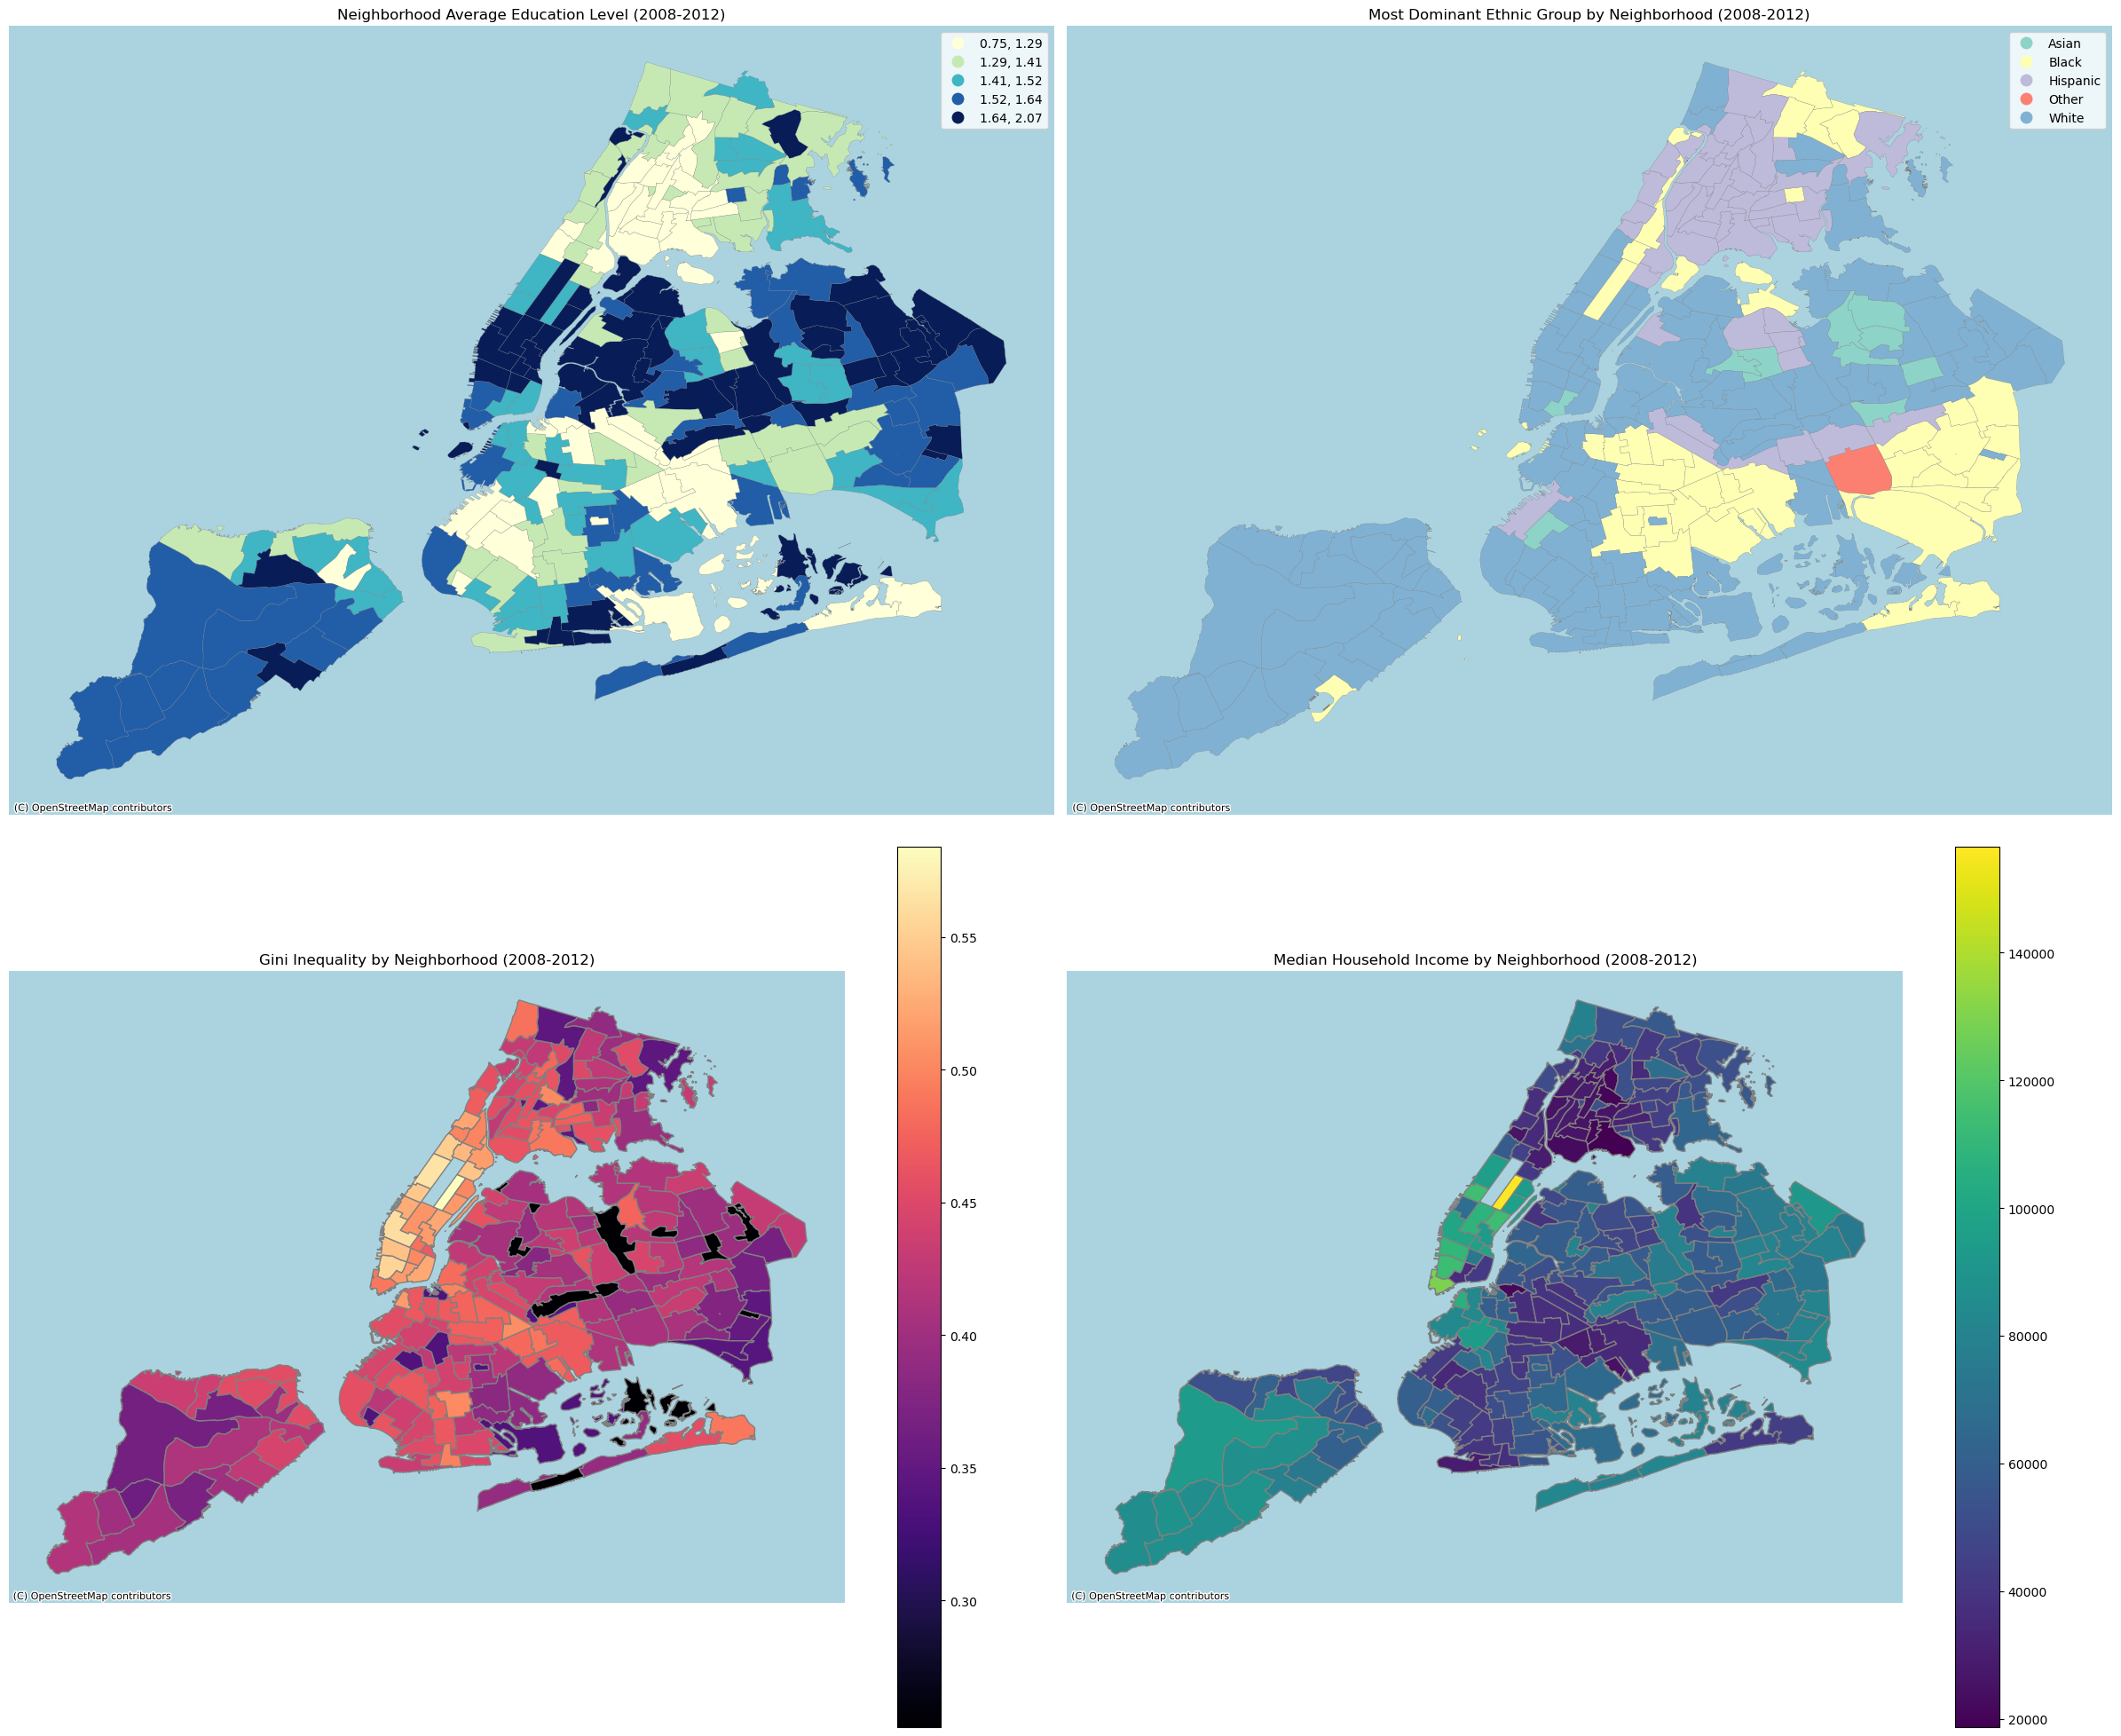

In [337]:

fig, axes = plt.subplots(2, 2, figsize=(24, 20))

# Education Score
vals = neighborhood_data['edu_score'].fillna(0)
scheme = mapclassify.Quantiles(vals, k=5)
neighborhood_data.plot(
    column='edu_score', cmap='YlGnBu', linewidth=0.2, edgecolor='0.5',
    legend=True, ax=axes[0,0], scheme='Quantiles', k=5
)
cx.add_basemap(axes[0,0], source=cx.providers.OpenStreetMap.Mapnik)
axes[0,0].set_title('Neighborhood Average Education Level (2008-2012)')
axes[0,0].axis('off')

# Dominant Ethnicity
cats = neighborhood_data['dominant_ethnicity'].astype('category')
cmap = ListedColormap(plt.cm.Set3.colors[:len(cats.cat.categories)])
neighborhood_data.plot(
    column='dominant_ethnicity', categorical=True, legend=True,
    cmap=cmap, linewidth=0.2, edgecolor='0.5', ax=axes[0,1]
)
cx.add_basemap(axes[0,1], source=cx.providers.OpenStreetMap.Mapnik)
axes[0,1].set_title('Most Dominant Ethnic Group by Neighborhood (2008-2012)')
axes[0,1].axis('off')

# Gini Inequality
neighborhood_data.plot(
    column='gini', cmap='magma', legend=True, edgecolor='0.5', ax=axes[1,0]
)
cx.add_basemap(axes[1,0], source=cx.providers.OpenStreetMap.Mapnik, zoom=10)
axes[1,0].set_title('Gini Inequality by Neighborhood (2008-2012)')
axes[1,0].axis('off')

# Median Household Income
neighborhood_data.plot(
    column='medianinco', cmap='viridis', legend=True, edgecolor='0.5', ax=axes[1,1]
)
cx.add_basemap(axes[1,1], source=cx.providers.OpenStreetMap.Mapnik, zoom=10)
axes[1,1].set_title('Median Household Income by Neighborhood (2008-2012)')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()
